In [7]:
import pandas as pd
from pathlib import Path

# Base folder holding the 5 session subfolders (1..5), each with a result/*.csv
base_dir = Path('../../../exp-results/raihan/main-experiment/phase-two/non-jittering-3d')

# Mean and standard error of response_time_ms per folder (session)
rows = {}
for session in range(1, 6):
    csv_path = next((base_dir / str(session) / 'result').glob('*.csv'))
    rt = pd.read_csv(csv_path)['response_time_ms']
    rows[session] = {'mean': rt.mean(), 'sem': rt.sem(), 'n': rt.count()}

response_time_stats = pd.DataFrame.from_dict(rows, orient='index')
response_time_stats.index.name = 'session'
response_time_stats

,mean,sem,n
session,,,
1,17916.6,2413.919520,10
2,18595.5,4499.585243,10
3,10837.2,2420.907983,10
4,14839.2,2678.753013,10
5,12586.6,2004.027906,10


In [8]:
base_dir_4d = Path('../../../exp-results/raihan/main-experiment/phase-two/non-jittering-4d')

rows_4d = {}
for session in range(1, 16):
    csv_path = next((base_dir_4d / str(session) / 'result').glob('*.csv'))
    rt = pd.read_csv(csv_path)['response_time_ms']
    rows_4d[session] = {'mean': rt.mean(), 'sem': rt.sem(), 'n': rt.count()}

response_time_stats_4d = pd.DataFrame.from_dict(rows_4d, orient='index')
response_time_stats_4d.index.name = 'session'
response_time_stats_4d

,mean,sem,n
session,,,
1,10926.2,2750.453962,10
2,8165.1,1936.027729,10
3,8225.8,1508.989108,10
4,9818.2,1525.948061,10
5,3584.1,639.356733,10
6,10311.6,2625.305020,10
7,20945.7,7120.737460,10
8,35523.7,13508.766800,10
9,16267.5,2020.833284,10


In [9]:
def pool_response_times(base_dir, sessions):
    values = []
    for session in sessions:
        csv_path = next((base_dir / str(session) / 'result').glob('*.csv'))
        values.append(pd.read_csv(csv_path)['response_time_ms'])
    return pd.concat(values, ignore_index=True)

rt_3d_all = pool_response_times(base_dir, range(1, 6))      # 5 sessions
rt_4d_all = pool_response_times(base_dir_4d, range(1, 16))  # 15 sessions

response_time_total = pd.DataFrame({
    'mean': [rt_3d_all.mean(), rt_4d_all.mean()],
    'sem': [rt_3d_all.sem(), rt_4d_all.sem()],
    'n': [rt_3d_all.count(), rt_4d_all.count()],
}, index=['3d', '4d'])
response_time_total.index.name = 'condition'
response_time_total

,mean,sem,n
condition,,,
3d,14955.02,1329.011544,50
4d,14152.90,1421.037357,150


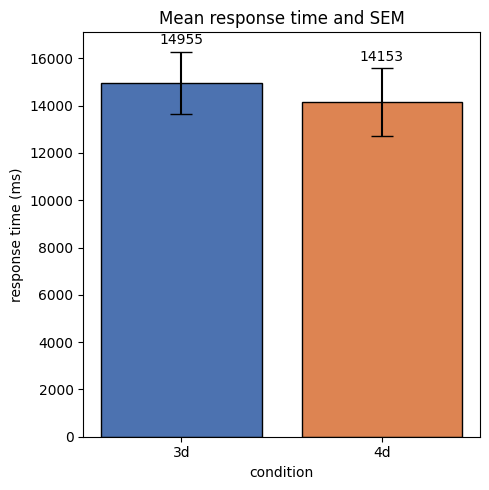

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(
    response_time_total.index,
    response_time_total['mean'],
    yerr=response_time_total['sem'],
    capsize=8,
    color=['#4C72B0', '#DD8452'],
    edgecolor='black',
)
ax.set_xlabel('condition')
ax.set_ylabel('response time (ms)')
ax.set_title('Mean response time and SEM')

# annotate each bar with its mean value
for i, (mean, sem) in enumerate(zip(response_time_total['mean'], response_time_total['sem'])):
    ax.text(i, mean + sem + 200, f'{mean:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()